In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json, os, joblib
from scipy import signal

# EXTRAINDO DADOS

In [2]:
OPTIONS = json.loads(open('info.json', 'rb').read())
TARGETS = OPTIONS['target_var']
SEEVAR  = OPTIONS['seevar']
N_ITER  = OPTIONS['n_iter']
K_CV    = OPTIONS['k_cv']
MODEL   = OPTIONS['model']
dt = OPTIONS['dt']
OPTIONS

{'target_var': ['pitch', 'roll'],
 'seevar': 'wx',
 'n_states': 30,
 'k_cv': 5,
 'model': 'linear_regression',
 'n_iter': 15000,
 'dt': 0.1}

In [3]:
df = pd.read_csv('Backup/model.csv')
TEMPORAL = True
df

,time,wx,wx(n-1),wx(n-2),wx(n-3),wx(n-4),wx(n-5),wx(n-6),wx(n-7),wx(n-8),...,az(n-22),az(n-23),az(n-24),az(n-25),az(n-26),az(n-27),az(n-28),az(n-29),pitch,roll
0,2.9,-61.81249,-55.61883,-46.32656,-35.58222,-22.03634,-7.44627,7.68209,21.68968,35.98178,...,0.216609,0.057094,-0.152699,-0.208931,-0.455019,-2.312996,-0.532550,-0.614769,0.455501,-83.995613
1,3.0,-64.39786,-61.81249,-55.61883,-46.32656,-35.58222,-22.03634,-7.44627,7.68209,21.68968,...,0.149904,0.216609,0.057094,-0.152699,-0.208931,-0.455019,-2.312996,-0.532550,0.479107,-90.355444
2,3.1,-63.49374,-64.39786,-61.81249,-55.61883,-46.32656,-35.58222,-22.03634,-7.44627,7.68209,...,0.129869,0.149904,0.216609,0.057094,-0.152699,-0.208931,-0.455019,-2.312996,0.513829,-96.772572
3,3.2,-58.50891,-63.49374,-64.39786,-61.81249,-55.61883,-46.32656,-35.58222,-22.03634,-7.44627,...,0.124652,0.129869,0.149904,0.216609,0.057094,-0.152699,-0.208931,-0.455019,0.541159,-102.903220
4,3.3,-51.22703,-58.50891,-63.49374,-64.39786,-61.81249,-55.61883,-46.32656,-35.58222,-22.03634,...,0.067499,0.124652,0.129869,0.149904,0.216609,0.057094,-0.152699,-0.208931,0.561269,-108.403615
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1737,279.4,-0.09321,-0.12105,0.48312,0.10422,-0.25356,-0.22814,-0.03384,0.08034,0.05928,...,-0.427992,-0.433375,-0.427256,-0.451910,-0.420941,-0.420293,-0.449851,-0.423520,1.644962,-92.131613
1738,279.5,-0.09929,-0.09321,-0.12105,0.48312,0.10422,-0.25356,-0.22814,-0.03384,0.08034,...,-0.430512,-0.427992,-0.433375,-0.427256,-0.451910,-0.420941,-0.420293,-0.449851,1.645535,-92.131613
1739,279.6,-0.18597,-0.09929,-0.09321,-0.12105,0.48312,0.10422,-0.25356,-0.22814,-0.03384,...,-0.420225,-0.430512,-0.427992,-0.433375,-0.427256,-0.451910,-0.420941,-0.420293,1.644962,-92.131613
1740,279.7,0.06592,-0.18597,-0.09929,-0.09321,-0.12105,0.48312,0.10422,-0.25356,-0.22814,...,-0.427599,-0.420225,-0.430512,-0.427992,-0.433375,-0.427256,-0.451910,-0.420941,1.645535,-92.131613


In [4]:
xData = df.drop(columns=['time'] + TARGETS)
yData = df[TARGETS]

N_STATES = len(xData.columns)
print('n states: ', N_STATES, '| saídas:', TARGETS)

xData

n states:  180 | saídas: ['pitch', 'roll']


,wx,wx(n-1),wx(n-2),wx(n-3),wx(n-4),wx(n-5),wx(n-6),wx(n-7),wx(n-8),wx(n-9),...,az(n-20),az(n-21),az(n-22),az(n-23),az(n-24),az(n-25),az(n-26),az(n-27),az(n-28),az(n-29)
0,-61.81249,-55.61883,-46.32656,-35.58222,-22.03634,-7.44627,7.68209,21.68968,35.98178,47.71620,...,0.129869,0.149904,0.216609,0.057094,-0.152699,-0.208931,-0.455019,-2.312996,-0.532550,-0.614769
1,-64.39786,-61.81249,-55.61883,-46.32656,-35.58222,-22.03634,-7.44627,7.68209,21.68968,35.98178,...,0.124652,0.129869,0.149904,0.216609,0.057094,-0.152699,-0.208931,-0.455019,-2.312996,-0.532550
2,-63.49374,-64.39786,-61.81249,-55.61883,-46.32656,-35.58222,-22.03634,-7.44627,7.68209,21.68968,...,0.067499,0.124652,0.129869,0.149904,0.216609,0.057094,-0.152699,-0.208931,-0.455019,-2.312996
3,-58.50891,-63.49374,-64.39786,-61.81249,-55.61883,-46.32656,-35.58222,-22.03634,-7.44627,7.68209,...,0.113443,0.067499,0.124652,0.129869,0.149904,0.216609,0.057094,-0.152699,-0.208931,-0.455019
4,-51.22703,-58.50891,-63.49374,-64.39786,-61.81249,-55.61883,-46.32656,-35.58222,-22.03634,-7.44627,...,-0.019407,0.113443,0.067499,0.124652,0.129869,0.149904,0.216609,0.057094,-0.152699,-0.208931
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1737,-0.09321,-0.12105,0.48312,0.10422,-0.25356,-0.22814,-0.03384,0.08034,0.05928,-0.11949,...,-0.420225,-0.430512,-0.427992,-0.433375,-0.427256,-0.451910,-0.420941,-0.420293,-0.449851,-0.423520
1738,-0.09929,-0.09321,-0.12105,0.48312,0.10422,-0.25356,-0.22814,-0.03384,0.08034,0.05928,...,-0.427599,-0.420225,-0.430512,-0.427992,-0.433375,-0.427256,-0.451910,-0.420941,-0.420293,-0.449851
1739,-0.18597,-0.09929,-0.09321,-0.12105,0.48312,0.10422,-0.25356,-0.22814,-0.03384,0.08034,...,-0.476299,-0.427599,-0.420225,-0.430512,-0.427992,-0.433375,-0.427256,-0.451910,-0.420941,-0.420293
1740,0.06592,-0.18597,-0.09929,-0.09321,-0.12105,0.48312,0.10422,-0.25356,-0.22814,-0.03384,...,-0.439662,-0.476299,-0.427599,-0.420225,-0.430512,-0.427992,-0.433375,-0.427256,-0.451910,-0.420941


# SELECIONANDO MODELO

In [5]:
from Selector.index import ModelSelector

In [6]:
selector = ModelSelector(MODEL, len(TARGETS))
model, params = selector.get()
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


# APLICANDO GRID SEARCH TEMPORAL

In [7]:
from RandomSearch.index import RandomSearch

In [8]:
grid = RandomSearch(model, params, xData, yData, K_CV, temporal=TEMPORAL, n_iter=N_ITER)
grid.update()

model, r2_adj = grid.evaluate()
print('best_R2_Adjusted:', r2_adj)
model

Fitting 5 folds for each of 4 candidates, totalling 20 fits


/home/klauss/miniconda3/lib/python3.13/site-packages/sklearn/model_selection/_search.py:324: UserWarning: The total space of parameters 4 is smaller than n_iter=15000. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


best_R2_Adjusted: 0.08049579126508144


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


# AVALIAÇÃO GAUSSIANA
O valor mais provável em uma distribuição gaussiana é a média, com a relação

$$\mu \pm t\cdot\frac{\sigma_a}{\sqrt{n}}$$

- $\sigma_a$ é o desvio padrão amostral, considerando $n-1$ graus de liberade (ddof no numpy)
- $\mu$ é a média
- $t$ é o t_student para corrigir a amostra com $n$-1 e aqui vamos adotar a tabela para 95% de confiança (os dados vão cair em um intervalo $\pm$ ... com 95% de confiança) 

In [9]:
from Metrics.CrossValidation.index import CrossValidation
from Metrics.GaussianAnalyser.index import GaussianAnalyser

In [10]:
cross = CrossValidation(model, xData, yData, K_CV, temporal=TEMPORAL)
cross.update()

if not TEMPORAL:
    analyser = GaussianAnalyser(cross)
    analyser.update()
    analyser.plot()
    analyser.info()

# RESULTADOS
- `r2` é a média do R² das saídas e `r2_<ângulo>` é o R² de cada uma, para a média não esconder um ângulo ruim

In [11]:
from Metrics.Plotter.index import Plotter

In [12]:
cross.print()

R2: 0.7192 (±0.1039)
R2_ADJ: 0.4177 (±0.2141)
RMSE: 0.2686 (±0.0562) [Erro Absoluto]
MAE: 0.2134 (±0.0347) [Erro Absoluto]
R2_PITCH: 0.4390 (±0.2078)
R2_ROLL: 0.9994 (±0.0002)


,name,values,mean,std,min,max,split_1,split_2,split_3,split_4,split_5
0,R2,"[0.5547386496383919, 0.7805083411669032, 0.639...",0.719198,0.103885,0.554739,0.816751,0.554739,0.780508,0.639467,0.804526,0.816751
1,R2_ADJ,"[0.08049579126508144, 0.5439305052988945, 0.25...",0.417674,0.214063,0.080496,0.619238,0.080496,0.543931,0.250870,0.593835,0.619238
2,RMSE,"[0.3574712735772306, 0.2643440576172871, 0.300...",0.268598,0.056218,0.201566,0.357471,0.357471,0.264344,0.300041,0.219569,0.201566
3,MAE,"[0.2621639358019623, 0.21087109268941195, 0.24...",0.213355,0.034666,0.170637,0.262164,0.262164,0.210871,0.241458,0.181644,0.170637
4,R2_PITCH,"[0.11000139129741404, 0.5615033391462844, 0.27...",0.439007,0.207834,0.110001,0.634467,0.110001,0.561503,0.279516,0.609545,0.634467
5,R2_ROLL,"[0.9994759079793699, 0.9995133431875219, 0.999...",0.999390,0.000180,0.999036,0.999513,0.999476,0.999513,0.999419,0.999506,0.999036


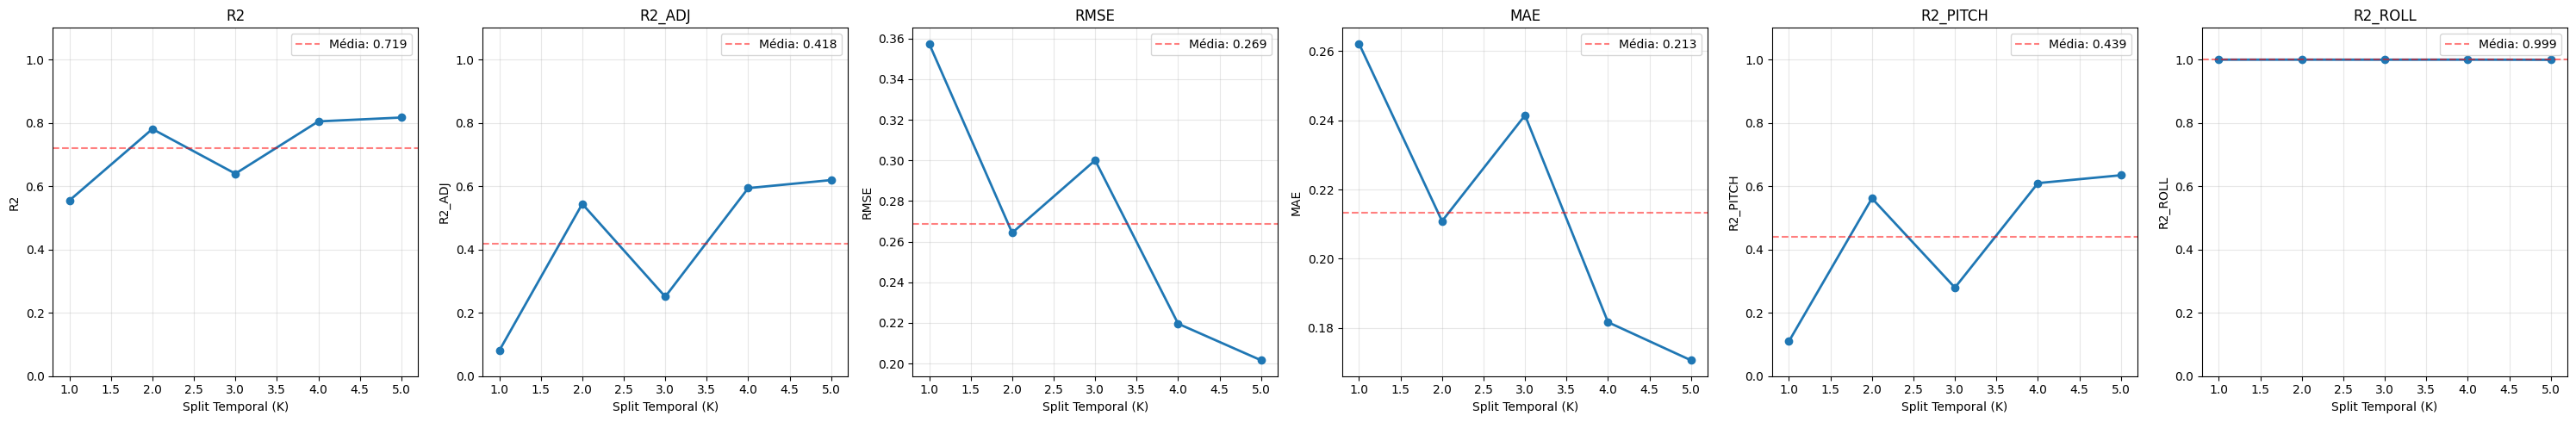

In [13]:
cross.plot()

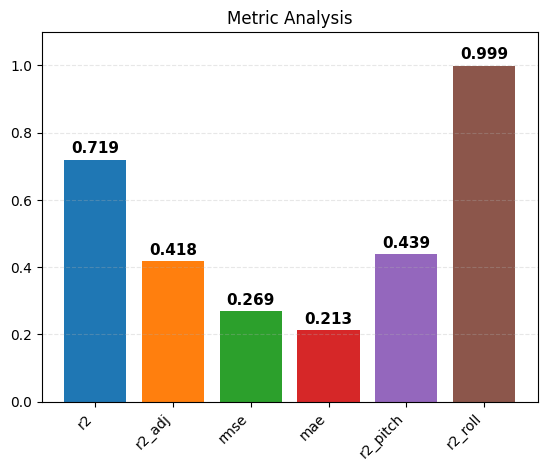

In [14]:
R2 = cross.info()['r2']
Plotter(cross.info(), limits=(0, max(list(cross.info().values()))*1.1))

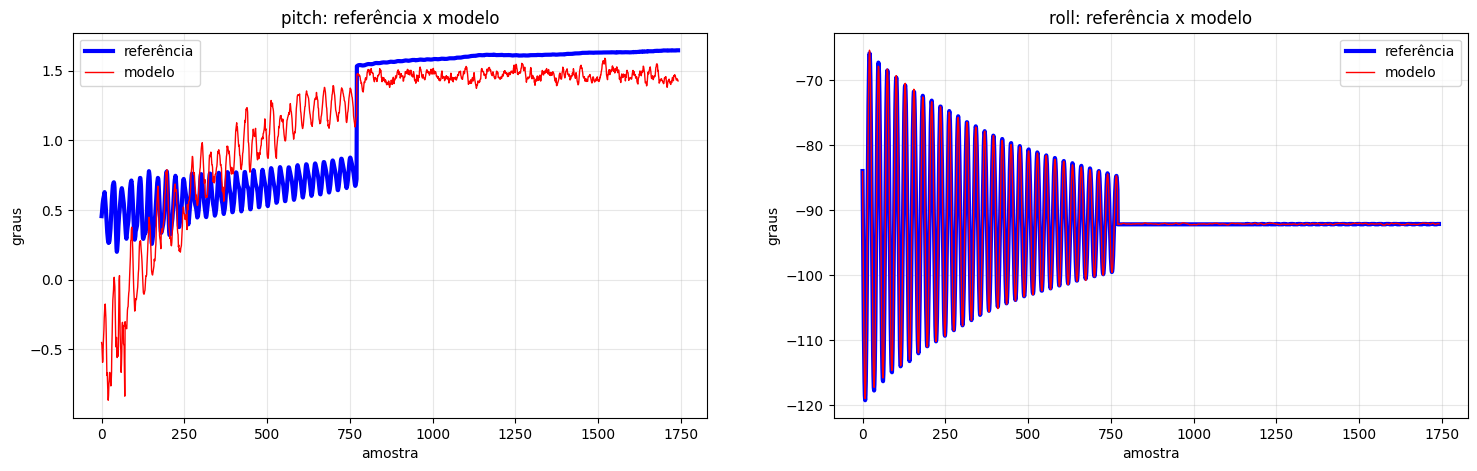

In [15]:
result = pd.DataFrame(model.predict(xData), columns=TARGETS)

plt.figure(figsize=(9*len(TARGETS), 5))

for i, target in enumerate(TARGETS):
    plt.subplot(1, len(TARGETS), i+1)
    plt.plot(df[target], label='referência', color='blue', linewidth=3)
    plt.plot(result[target], label='modelo', color='red', linewidth=1)

    plt.title(f'{target}: referência x modelo'); plt.xlabel('amostra'); plt.ylabel('graus')
    plt.grid(alpha=0.3); plt.legend()

plt.show()

# TREINANDO MODELO FINAL

In [16]:
model.fit(xData, yData)
model.get_params()

{'memory': None,
 'steps': [('scaler', StandardScaler()), ('model', LinearRegression())],
 'transform_input': None,
 'verbose': False,
 'scaler': StandardScaler(),
 'model': LinearRegression(),
 'scaler__copy': True,
 'scaler__with_mean': True,
 'scaler__with_std': True,
 'model__copy_X': True,
 'model__fit_intercept': True,
 'model__n_jobs': None,
 'model__positive': False,
 'model__tol': 1e-06}

In [17]:
model

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [18]:
results = {
    'model': selector.chosen,
    'params': {key: str(value) for key, value in model.get_params().items()},
    'K_CV': K_CV,
    'info': analyser.info() if not TEMPORAL else cross.info(),
    'targets': TARGETS,
    'variables': xData.columns.tolist()
}

display(pd.DataFrame([results.get('info')]))
results

,r2,r2_adj,rmse,mae,r2_pitch,r2_roll
0,0.719198,0.417674,0.268598,0.213355,0.439007,0.99939


{'model': 'linear_regression',
 'params': {'memory': 'None',
  'steps': "[('scaler', StandardScaler()), ('model', LinearRegression())]",
  'transform_input': 'None',
  'verbose': 'False',
  'scaler': 'StandardScaler()',
  'model': 'LinearRegression()',
  'scaler__copy': 'True',
  'scaler__with_mean': 'True',
  'scaler__with_std': 'True',
  'model__copy_X': 'True',
  'model__fit_intercept': 'True',
  'model__n_jobs': 'None',
  'model__positive': 'False',
  'model__tol': '1e-06'},
 'K_CV': 5,
 'info': {'r2': 0.7191982774512693,
  'r2_adj': 0.41767364921520816,
  'rmse': 0.26859804469274645,
  'mae': 0.2133548115396772,
  'r2_pitch': 0.4390065306417948,
  'r2_roll': 0.9993900242607439},
 'targets': ['pitch', 'roll'],
 'variables': ['wx',
  'wx(n-1)',
  'wx(n-2)',
  'wx(n-3)',
  'wx(n-4)',
  'wx(n-5)',
  'wx(n-6)',
  'wx(n-7)',
  'wx(n-8)',
  'wx(n-9)',
  'wx(n-10)',
  'wx(n-11)',
  'wx(n-12)',
  'wx(n-13)',
  'wx(n-14)',
  'wx(n-15)',
  'wx(n-16)',
  'wx(n-17)',
  'wx(n-18)',
  'wx(n-19)'

In [19]:
os.makedirs('Backup', exist_ok=True)
saved  = [name for name in os.listdir('Backup') if name.startswith('model_')]    # O target.csv TEMPORÁRIO TAMBÉM MORA NO Backup
index  = len(saved) + 1

output = f'Backup/model_{index}'
os.makedirs(output, exist_ok=True)

pd.Series(results).to_json(os.path.join(output, 'info.json'), indent=4)
joblib.dump(model, os.path.join(output, 'model.pkl'))

['Backup/model_4/model.pkl']